# 策略 3：基于估值差的红利低波择时

使用 RQData 官方红利低波指数历史成份股和本地月末 PB 构造估值差。月末看空信号用于下一个月，并分别测试空仓与理论卖空情景。请先运行 `download.ipynb` 的官方指数、股票日行情和官方历史成份股下载单元。

In [1]:
import os
import sys
from pathlib import Path

project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
os.chdir(project_root)
source_root = project_root / 'src'
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

In [2]:
from importlib.resources import files

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yaml

from pyquant import calc_metrics, load_dataset
from strategies.dividend_low_vol.timing import (
    backtest_valuation_spread_timing,
    calculate_bp_spread,
)

plt.rcParams['font.family'] = 'STHeiti'
plt.rcParams['axes.unicode_minus'] = False

## 配置与本地数据

官方成份股文件只保存集合发生变化的快照。策略计算会为每个月末匹配不晚于该日期的最近快照。

In [3]:
with files('strategies.dividend_low_vol').joinpath('config.yaml').open(encoding='utf-8') as stream:
    config = yaml.safe_load(stream) or {}
start_date = pd.Timestamp(config['data']['start_date'])
end_date = pd.Timestamp(config['data']['end_date'])
month_start = start_date.to_period('M').start_time

price = load_dataset(
    'stock_daily',
    start=month_start.strftime('%Y-%m-%d'),
    end=end_date.strftime('%Y-%m-%d'),
)
constituents = load_dataset('index_constituents')
benchmark = load_dataset(
    'csindex_daily',
    start=month_start.strftime('%Y-%m-%d'),
    end=end_date.strftime('%Y-%m-%d'),
    symbols=['H20269'],
).set_index('date')['close'].rename('红利低波全收益指数')

## 估值差与看空信号

两组股票分别剔除 BP 最高和最低的 10%，再计算均值。下轨使用包含当月的最近 6 个月估值差总体标准差。

In [4]:
spread = calculate_bp_spread(price, constituents, config)
timing = backtest_valuation_spread_timing(spread, benchmark)
print(f"BP spread months: {len(spread)}")
print(f"Bearish signals: {int(spread['bearish_signal'].sum())}")

BP spread months: 114
Bearish signals: 15


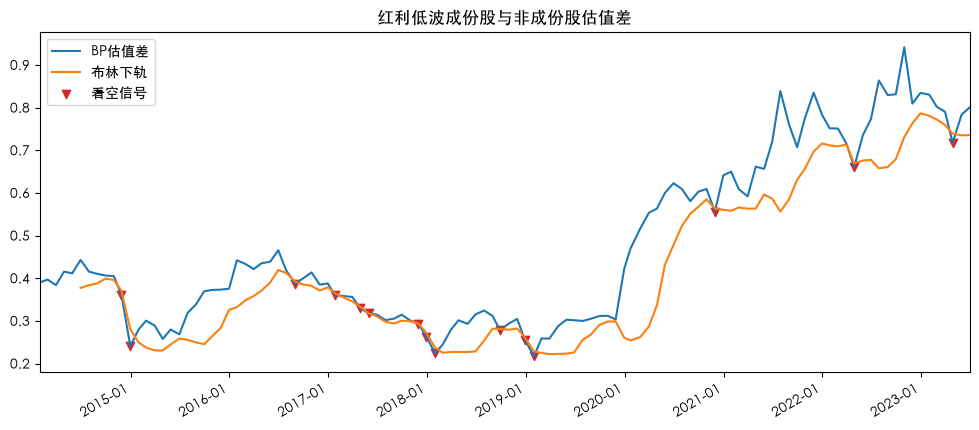

In [5]:
ax = spread[['bp_spread', 'lower_band']].rename(
    columns={'bp_spread': 'BP估值差', 'lower_band': '布林下轨'}
).plot(figsize=(12, 5), title='红利低波成份股与非成份股估值差')
bearish = spread[spread['bearish_signal']]
ax.scatter(bearish.index, bearish['bp_spread'], color='C3', marker='v', label='看空信号')
ax.margins(x=0)
ax.set_xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend()
plt.show()

## 月度收益与估值差

左轴展示红利低波全收益指数月度收益，右轴展示 BP 估值差。

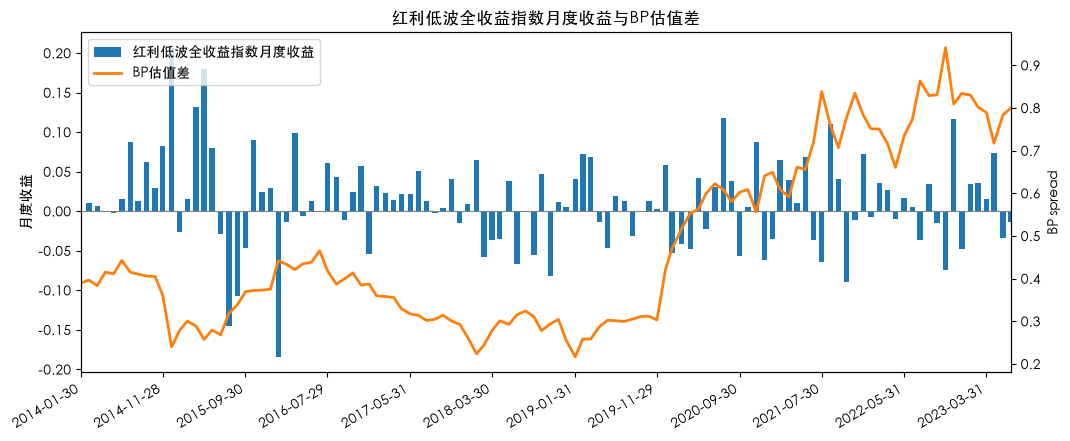

In [6]:
figure, left_axis = plt.subplots(figsize=(12, 5))
bars = left_axis.bar(
    timing.index,
    timing['benchmark_return'],
    width=20,
    color='C0',
    label='红利低波全收益指数月度收益',
)
left_axis.axhline(0, color='#808080', linewidth=0.8)
left_axis.set_ylabel('月度收益')
right_axis = left_axis.twinx()
line, = right_axis.plot(
    spread.index,
    spread['bp_spread'],
    color='C1',
    linewidth=2,
    label='BP估值差',
)
right_axis.set_ylabel('BP spread')
left_axis.set_title('红利低波全收益指数月度收益与BP估值差')
left_axis.margins(x=0)
left_axis.set_xlabel('')
left_axis.set_xlim(timing.index.min(), timing.index.max())
left_axis.set_xticks(timing.index[::10])
left_axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
left_axis.legend([bars, line], [bars.get_label(), line.get_label()], loc='upper left')
figure.autofmt_xdate()
plt.show()

## 次月择时净值

卖空结果未计入融券费、保证金和卖空可行性约束，仅代表研报定义下的理论情景。

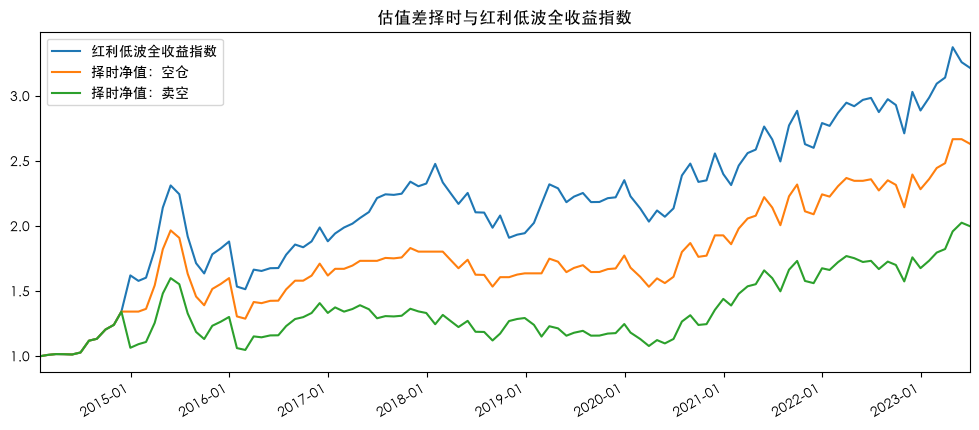

In [7]:
nav = timing[['benchmark_nav', 'cash_timing_nav', 'short_timing_nav']].rename(
    columns={
        'benchmark_nav': '红利低波全收益指数',
        'cash_timing_nav': '择时净值：空仓',
        'short_timing_nav': '择时净值：卖空',
    }
)
ax = nav.plot(figsize=(12, 5), title='估值差择时与红利低波全收益指数')
ax.margins(x=0)
ax.set_xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.show()

## 绩效对比

信息比率按研报表格口径计算为年化收益除以年化波动；月度胜率为月收益大于零的比例。

In [8]:
returns = timing[['benchmark_return', 'cash_timing_return', 'short_timing_return']].rename(
    columns={
        'benchmark_return': '红利低波全收益指数',
        'cash_timing_return': '择时净值：空仓',
        'short_timing_return': '择时净值：卖空',
    }
)

def summarize_performance(monthly_returns):
    metrics = calc_metrics(monthly_returns, periods_per_year=12)
    return pd.Series(
        {
            '年化收益': metrics['annual_return'],
            '年化波动': metrics['annual_vol'],
            '信息比率': metrics['sharpe'],
            '月度胜率': (monthly_returns.dropna() > 0).mean(),
            '最大回撤': metrics['max_drawdown'],
        }
    )

performance = returns.apply(summarize_performance)
performance.style.format({
    '年化收益': '{:.2%}',
    '年化波动': '{:.2%}',
    '信息比率': '{:.2f}',
    '月度胜率': '{:.2%}',
    '最大回撤': '{:.2%}',
})

,红利低波全收益指数,择时净值：空仓,择时净值：卖空
年化收益,0.132156,0.108332,0.076418
年化波动,0.201022,0.181985,0.203484
信息比率,0.657424,0.595278,0.375549
月度胜率,0.619469,0.539823,0.592920
最大回撤,-0.344779,-0.344779,-0.344779


## 看空持仓月份

`signal_date` 是信号形成月末，表格索引是信号实际作用的下一个月末。

In [9]:
bearish_months = timing.loc[
    timing['bearish_position'],
    ['signal_date', 'benchmark_return'],
].copy()
bearish_months['是否看对'] = bearish_months['benchmark_return'].lt(0)
bearish_months['benchmark_return'] = bearish_months['benchmark_return'].map('{:.2%}'.format)
bearish_months.rename(columns={'signal_date': '信号日期', 'benchmark_return': '指数当月收益'})

,信号日期,指数当月收益,是否看对
date,,,
2014-12-31,2014-11-28,20.70%,False
2015-01-30,2014-12-31,-2.60%,True
2016-09-30,2016-08-31,-1.13%,True
2017-02-28,2017-01-26,2.36%,False
2017-05-31,2017-04-28,2.23%,False
2017-06-30,2017-05-31,5.10%,False
2017-12-29,2017-11-30,0.90%,False
2018-01-31,2017-12-29,6.49%,False
2018-02-28,2018-01-31,-5.75%,True


## 口径与风险

- 成份归属来自 RQData 官方历史成份股，价格指数与全收益指数共用成份股。
- 本地行情不保留停牌日；每只股票使用不晚于市场月末的当月最后一条有效 PB。
- 缺失或为零的 PB 不参与当月均值；输出保留两组实际样本数。
- 看空信号严格作用于下月，避免未来函数。
- 卖空情景未模拟融券约束和相关成本。